<a href="https://colab.research.google.com/github/nikithadayanand04/FileExplorer/blob/main/PalmPayModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


PHASE-1: DATASET VALIDATION

In [59]:
import os
import cv2
import numpy as np
import pandas as pd

HAND_PATH = "/content/drive/MyDrive/PalmVeinProject/Hand_Dataset"
VEIN_PATH = "/content/drive/MyDrive/PalmVeinProject/Veins_Dataset"

In [61]:
import os

subjects = sorted([
    s for s in os.listdir(HAND_PATH)
    if os.path.isdir(os.path.join(HAND_PATH, s))
])

print("Total Subjects:", len(subjects))

total_images = 0

for subject in subjects:

    subject_path = os.path.join(HAND_PATH, subject)

    total_images += len([
        f for f in os.listdir(subject_path)
        if f.lower().endswith('.bmp')
    ])

print("Total Images:", total_images)

Total Subjects: 60
Total Images: 600


In [67]:
sizes = []

for subject in subjects:

    folder = os.path.join(HAND_PATH, subject)

    for img_name in os.listdir(folder):

        path = os.path.join(folder, img_name)

        img = cv2.imread(path, 0)

        sizes.append(img.shape)

print(pd.Series(sizes).value_counts())

(480, 640)    600
Name: count, dtype: int64


PHASE-2: ROI EXTRACTION

Cell 1 — Import Libraries

In [75]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Cell 2 — Load Sample Image

Shape: (480, 640)


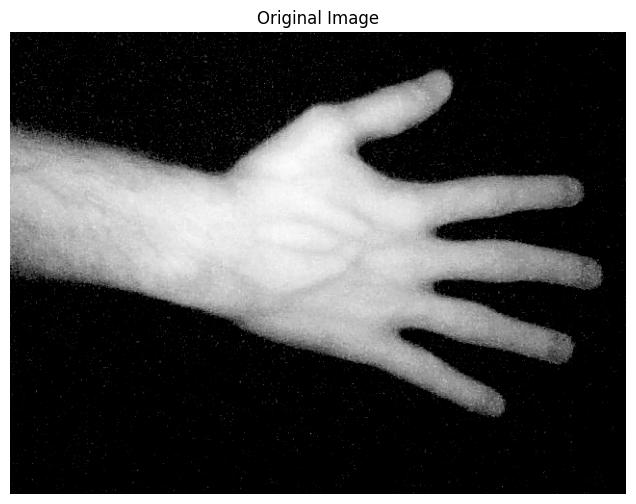

In [76]:
sample_path = f"{HAND_PATH}/s1/1.bmp"

img = cv2.imread(
    sample_path,
    cv2.IMREAD_GRAYSCALE
)

print("Shape:", img.shape)

plt.figure(figsize=(8,6))
plt.imshow(img,cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

Cell 3 — Hand Segmentation

In [77]:
def segment_hand(img):

    blur = cv2.GaussianBlur(
        img,
        (5,5),
        0
    )

    _, mask = cv2.threshold(
        blur,
        20,
        255,
        cv2.THRESH_BINARY
    )

    kernel = np.ones((5,5),np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    return mask

Cell 4 — Visualize Hand Mask

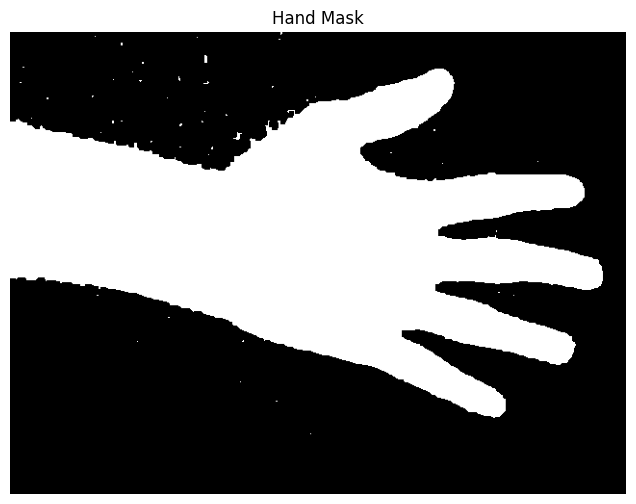

In [78]:
mask = segment_hand(img)

plt.figure(figsize=(8,6))
plt.imshow(mask,cmap='gray')
plt.title("Hand Mask")
plt.axis('off')
plt.show()

Cell 5 — Find Largest Contour

In [79]:
def get_largest_contour(mask):

    contours,_ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    largest = max(
        contours,
        key=cv2.contourArea
    )

    return largest

Cell 6 — Draw Contour

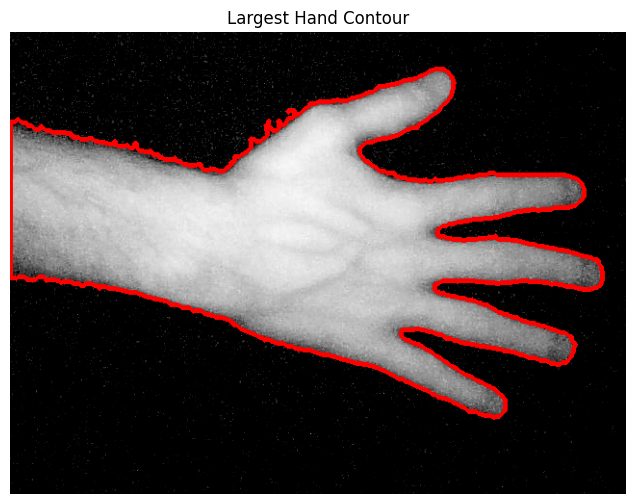

In [80]:
contour = get_largest_contour(mask)

rgb = cv2.cvtColor(
    img,
    cv2.COLOR_GRAY2RGB
)

cv2.drawContours(
    rgb,
    [contour],
    -1,
    (255,0,0),
    3
)

plt.figure(figsize=(8,6))
plt.imshow(rgb)
plt.title("Largest Hand Contour")
plt.axis('off')
plt.show()

Cell 7 — Palm Center Detection

In [81]:
def get_palm_center(contour):

    M = cv2.moments(contour)

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    return cx,cy

Cell 8 — Visualize Palm Center

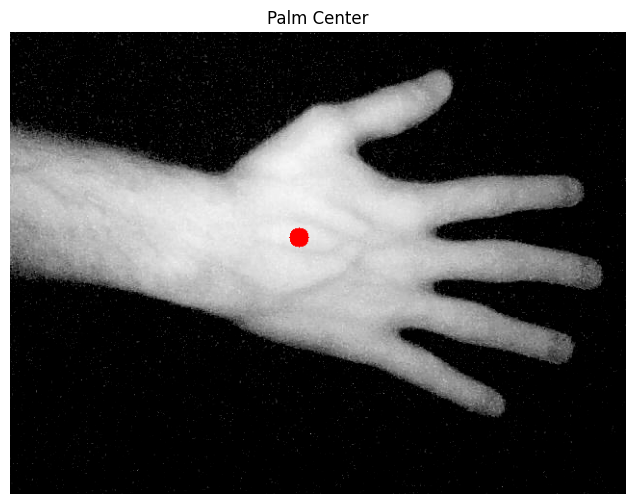

In [82]:
cx,cy = get_palm_center(contour)

rgb = cv2.cvtColor(
    img,
    cv2.COLOR_GRAY2RGB
)

cv2.circle(
    rgb,
    (cx,cy),
    10,
    (255,0,0),
    -1
)

plt.figure(figsize=(8,6))
plt.imshow(rgb)
plt.title("Palm Center")
plt.axis('off')
plt.show()

Cell 9 — Final ROI Extraction

In [83]:
def extract_palm_roi(img):

    mask = segment_hand(img)

    contour = get_largest_contour(mask)

    cx,cy = get_palm_center(contour)

    roi_size = 220

    x1 = max(cx - roi_size//2,0)
    y1 = max(cy - roi_size//2,0)

    x2 = min(cx + roi_size//2,img.shape[1])
    y2 = min(cy + roi_size//2,img.shape[0])

    roi = img[y1:y2,x1:x2]

    roi = cv2.resize(
        roi,
        (224,224)
    )

    return roi

Cell 10 — Generate ROI

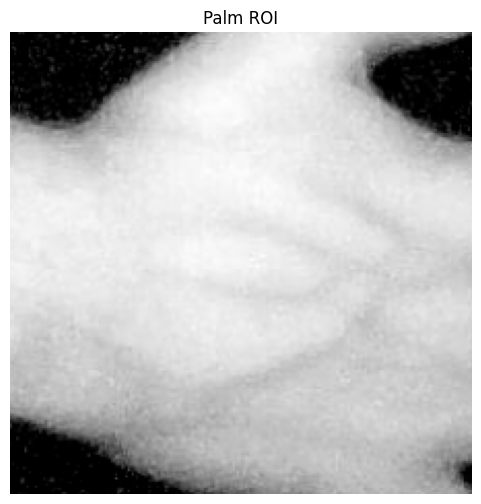

In [84]:
roi = extract_palm_roi(img)

plt.figure(figsize=(6,6))
plt.imshow(
    roi,
    cmap='gray'
)

plt.title("Palm ROI")
plt.axis('off')
plt.show()

Cell 11 — Verify ROI on Multiple Subjects

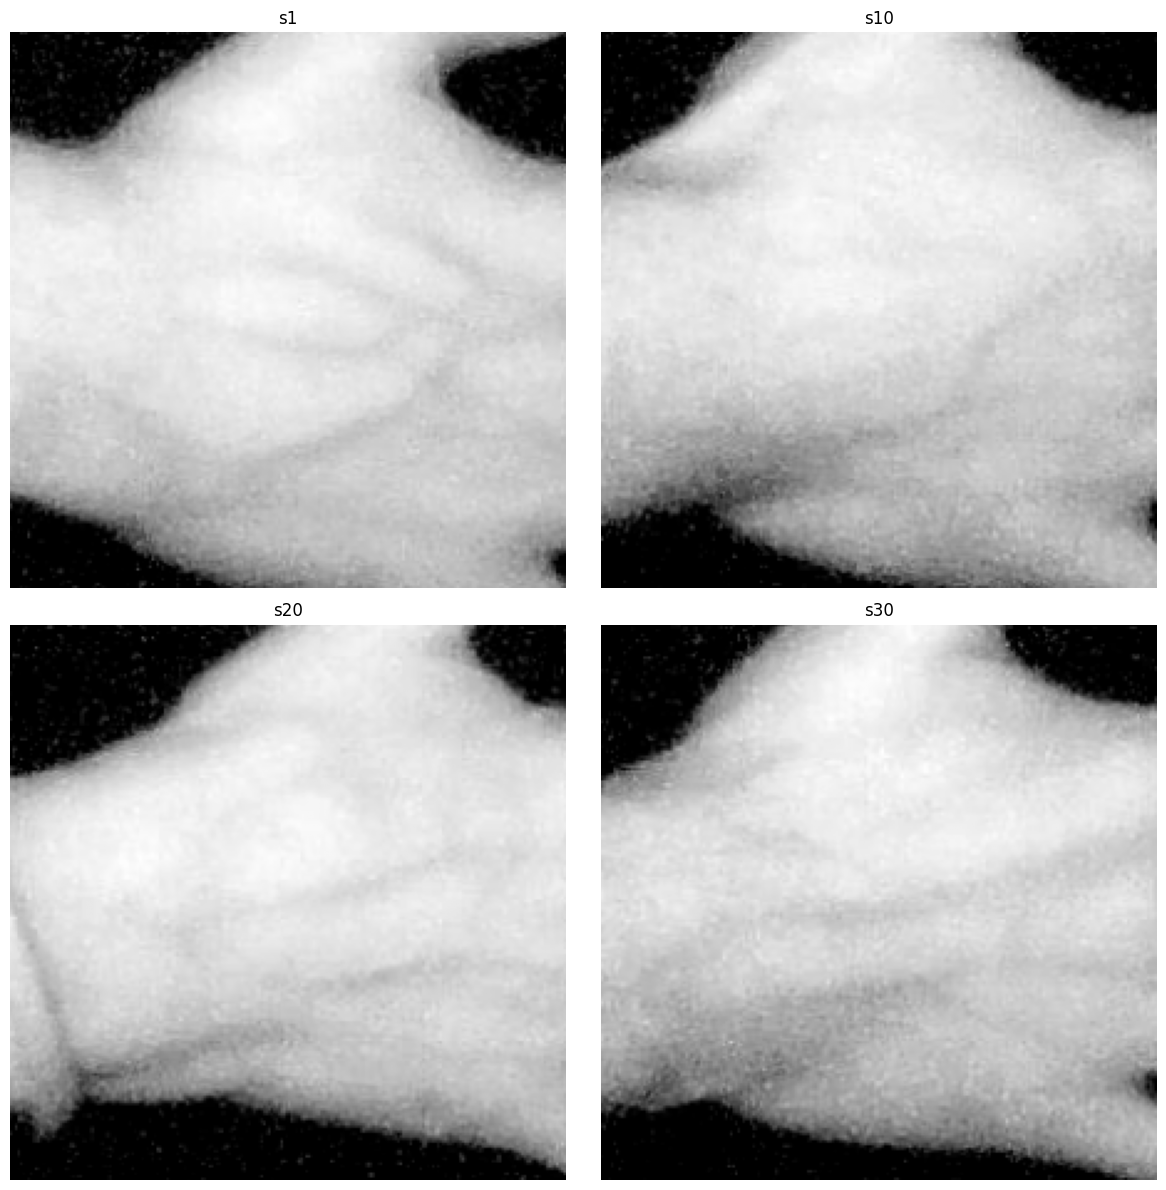

In [85]:
samples = [
    ("s1","1.bmp"),
    ("s10","1.bmp"),
    ("s20","1.bmp"),
    ("s30","1.bmp")
]

plt.figure(figsize=(12,12))

for i,(subject,image) in enumerate(samples):

    path = f"{HAND_PATH}/{subject}/{image}"

    img = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

    roi = extract_palm_roi(img)

    plt.subplot(2,2,i+1)
    plt.imshow(roi,cmap='gray')
    plt.title(subject)
    plt.axis('off')

plt.tight_layout()
plt.show()

PHASE 3 — PALM VEIN IMAGE ENHANCEMENT

CELL 1 — Denoising Function

In [114]:
def denoise_image(img):

    denoised = cv2.medianBlur(
        img,
        5
    )

    return denoised

CELL 2 — Apply Denoising

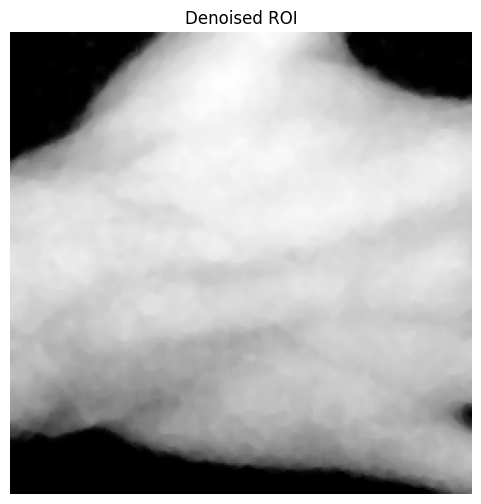

In [115]:
denoised = denoise_image(roi)

plt.figure(figsize=(6,6))

plt.imshow(
    denoised,
    cmap='gray'
)

plt.title(
    "Denoised ROI"
)

plt.axis('off')
plt.show()

CELL 3 — CLAHE Function

In [116]:
def apply_clahe(img):

    clahe = cv2.createCLAHE(
        clipLimit=3.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(img)

    return enhanced

CELL 4 — Apply CLAHE

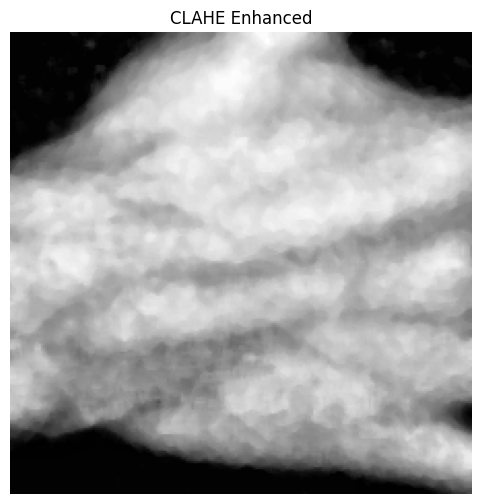

In [117]:
clahe_img = apply_clahe(
    denoised
)

plt.figure(figsize=(6,6))

plt.imshow(
    clahe_img,
    cmap='gray'
)

plt.title(
    "CLAHE Enhanced"
)

plt.axis('off')
plt.show()

CELL 5 — Gaussian Normalization Function

In [118]:
def gaussian_normalization(img):

    blur = cv2.GaussianBlur(
        img,
        (5,5),
        0
    )

    normalized = cv2.addWeighted(
        img,
        1.5,
        blur,
        -0.5,
        0
    )

    return normalized

CELL 6 — Apply Gaussian Normalization

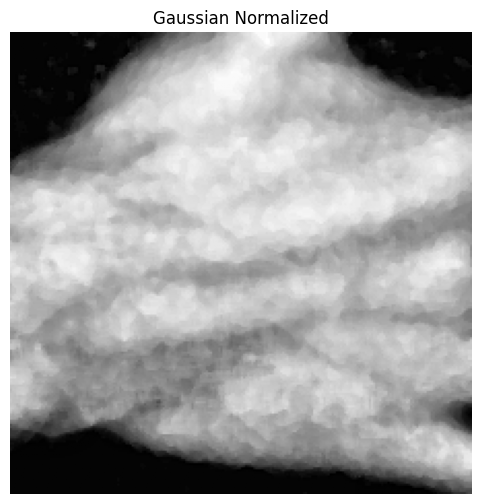

In [119]:
gaussian_img = gaussian_normalization(
    clahe_img
)

plt.figure(figsize=(6,6))

plt.imshow(
    gaussian_img,
    cmap='gray'
)

plt.title(
    "Gaussian Normalized"
)

plt.axis('off')
plt.show()

CELL 7 — Intensity Normalization Function

In [120]:
def normalize_image(img):

    normalized = cv2.normalize(
        img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return normalized.astype(
        np.uint8
    )

CELL 8 — Apply Intensity Normalization

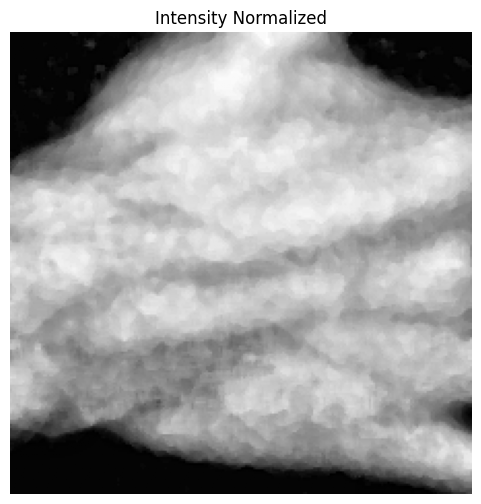

In [121]:
normalized_img = normalize_image(
    gaussian_img
)

plt.figure(figsize=(6,6))

plt.imshow(
    normalized_img,
    cmap='gray'
)

plt.title(
    "Intensity Normalized"
)

plt.axis('off')
plt.show()

CELL 9 — Gamma Correction Function

In [122]:
def gamma_correction(
    image,
    gamma=1.5
):

    image = image / 255.0

    corrected = np.power(
        image,
        gamma
    )

    corrected = corrected * 255

    return corrected.astype(
        np.uint8
    )

CELL 10 — Apply Gamma Correction

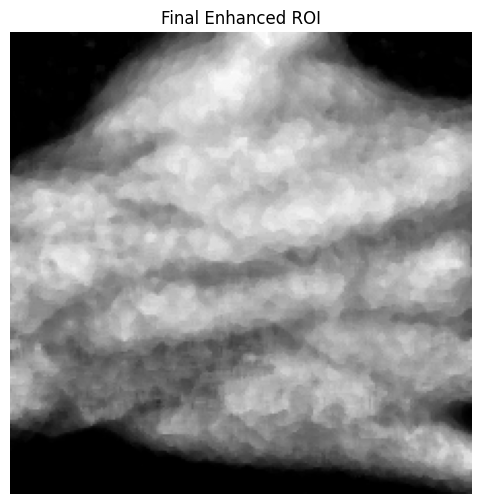

In [123]:
enhanced_roi = gamma_correction(
    normalized_img,
    gamma=1.5
)

plt.figure(figsize=(6,6))

plt.imshow(
    enhanced_roi,
    cmap='gray'
)

plt.title(
    "Final Enhanced ROI"
)

plt.axis('off')
plt.show()

CELL 11 — Complete Comparison

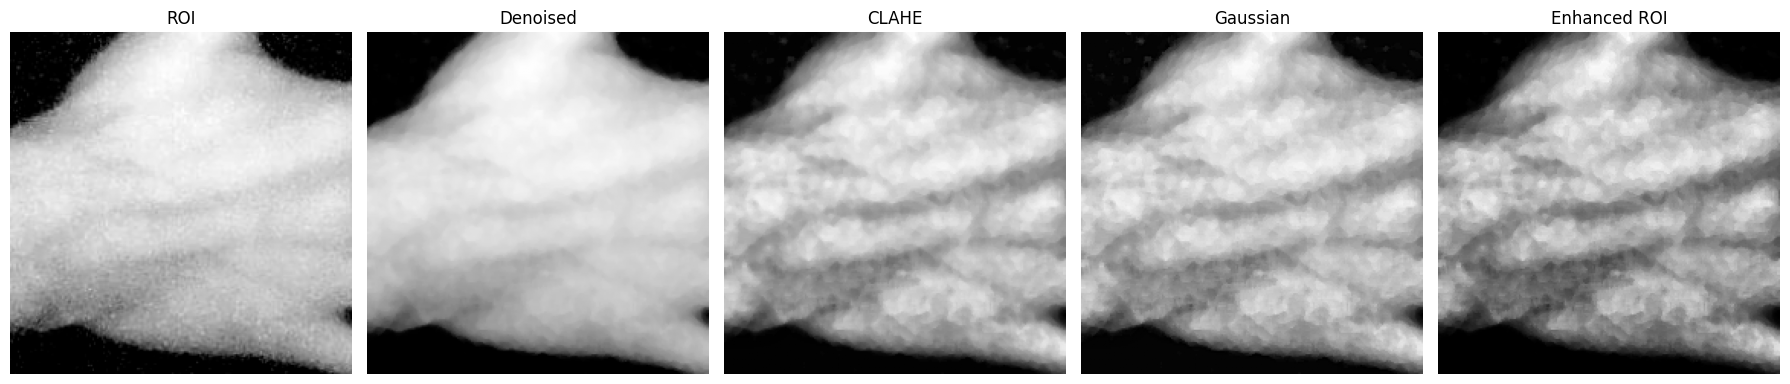

In [124]:
plt.figure(figsize=(18,5))

plt.subplot(1,5,1)
plt.imshow(
    roi,
    cmap='gray'
)
plt.title("ROI")
plt.axis('off')

plt.subplot(1,5,2)
plt.imshow(
    denoised,
    cmap='gray'
)
plt.title("Denoised")
plt.axis('off')

plt.subplot(1,5,3)
plt.imshow(
    clahe_img,
    cmap='gray'
)
plt.title("CLAHE")
plt.axis('off')

plt.subplot(1,5,4)
plt.imshow(
    gaussian_img,
    cmap='gray'
)
plt.title("Gaussian")
plt.axis('off')

plt.subplot(1,5,5)
plt.imshow(
    enhanced_roi,
    cmap='gray'
)
plt.title("Enhanced ROI")
plt.axis('off')

plt.tight_layout()
plt.show()

CELL 12 — Save Final ROI Variable

In [125]:
final_roi = enhanced_roi

print(
    "Final ROI Shape:",
    final_roi.shape
)

Final ROI Shape: (224, 224)


PHASE 4: DATASET PAIRING AND DATA PREPARATION FOR VEIN SEGMENTATION

CELL 1 — Imports

In [128]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

CELL 2 — Create Hand–Vein Image Pairs

In [129]:
pairs = []

subjects = sorted(
    [
        s for s in os.listdir(HAND_PATH)
        if os.path.isdir(
            os.path.join(HAND_PATH,s)
        )
    ]
)

for subject in subjects:

    hand_subject = os.path.join(
        HAND_PATH,
        subject
    )

    vein_subject = os.path.join(
        VEIN_PATH,
        subject
    )

    images = sorted(
        [
            f for f in os.listdir(hand_subject)
            if f.endswith(".bmp")
        ]
    )

    for img_name in images:

        image_path = os.path.join(
            hand_subject,
            img_name
        )

        mask_path = os.path.join(
            vein_subject,
            img_name
        )

        if os.path.exists(mask_path):

            pairs.append(
                [
                    subject,
                    image_path,
                    mask_path
                ]
            )

CELL 3 — Generate Dataset Metadata DataFrame

In [130]:
df = pd.DataFrame(
    pairs,
    columns=[
        "subject",
        "image_path",
        "mask_path"
    ]
)

print(df.shape)

df.head()

(600, 3)


,subject,image_path,mask_path
0,s1,/content/drive/MyDrive/PalmVeinProject/Hand_Da...,/content/drive/MyDrive/PalmVeinProject/Veins_D...
1,s1,/content/drive/MyDrive/PalmVeinProject/Hand_Da...,/content/drive/MyDrive/PalmVeinProject/Veins_D...
2,s1,/content/drive/MyDrive/PalmVeinProject/Hand_Da...,/content/drive/MyDrive/PalmVeinProject/Veins_D...
3,s1,/content/drive/MyDrive/PalmVeinProject/Hand_Da...,/content/drive/MyDrive/PalmVeinProject/Veins_D...
4,s1,/content/drive/MyDrive/PalmVeinProject/Hand_Da...,/content/drive/MyDrive/PalmVeinProject/Veins_D...


CELL 4 - Verify Image–Mask Pair Mapping

In [131]:
print(df.iloc[0]["image_path"])

print(df.iloc[0]["mask_path"])

/content/drive/MyDrive/PalmVeinProject/Hand_Dataset/s1/1.bmp
/content/drive/MyDrive/PalmVeinProject/Veins_Dataset/s1/1.bmp


CELL 5 - Define Subject-Wise Dataset Split

In [132]:
subjects = sorted(
    df.subject.unique()
)

train_subjects = subjects[:42]

val_subjects = subjects[42:51]

test_subjects = subjects[51:]

CELL 6 - Create Train, Validation, and Test Sets

In [133]:
train_df = df[
    df.subject.isin(
        train_subjects
    )
]

val_df = df[
    df.subject.isin(
        val_subjects
    )
]

test_df = df[
    df.subject.isin(
        test_subjects
    )
]

print(
    len(train_df),
    len(val_df),
    len(test_df)
)

420 90 90


CELL 7 - Verify Dataset Distribution

In [134]:
print(
    "Train Subjects:",
    len(train_subjects)
)

print(
    "Val Subjects:",
    len(val_subjects)
)

print(
    "Test Subjects:",
    len(test_subjects)
)

Train Subjects: 42
Val Subjects: 9
Test Subjects: 9


CELL 8 - Define Complete Image Preprocessing Pipeline

In [135]:
def preprocess_image(img):

    roi = extract_palm_roi(img)

    denoised = denoise_image(
        roi
    )

    clahe_img = apply_clahe(
        denoised
    )

    gaussian_img = gaussian_normalization(
        clahe_img
    )

    normalized_img = normalize_image(
        gaussian_img
    )

    enhanced_roi = gamma_correction(
        normalized_img,
        gamma=1.5
    )

    return enhanced_roi

CELL 9 - Validate Preprocessing Pipeline

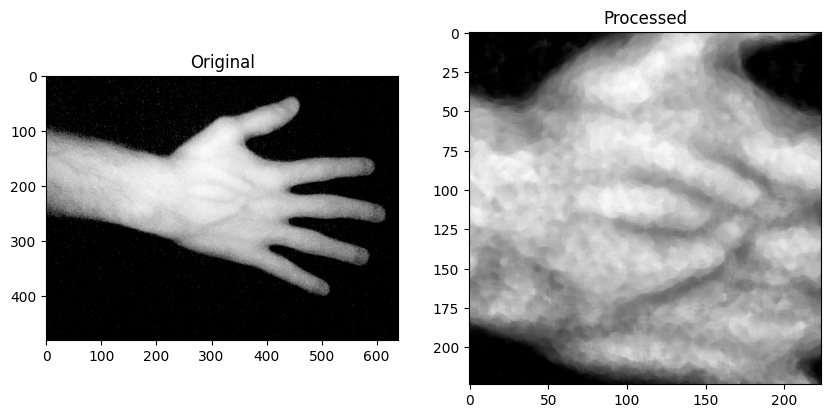

In [136]:
sample_img = cv2.imread(
    train_df.iloc[0]["image_path"],
    cv2.IMREAD_GRAYSCALE
)

processed = preprocess_image(
    sample_img
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(
    sample_img,
    cmap='gray'
)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(
    processed,
    cmap='gray'
)
plt.title("Processed")

plt.show()

CELL 10 - Load Ground Truth Vein Mask

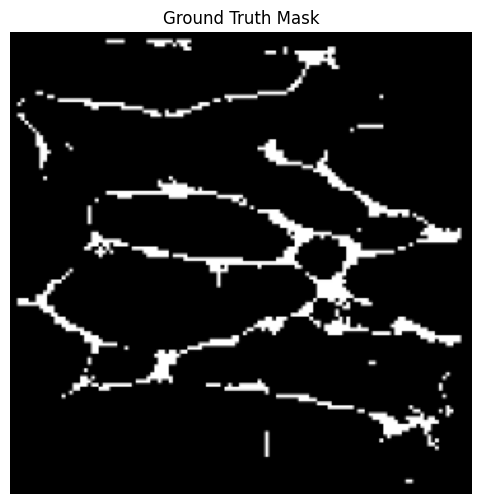

In [137]:
mask = cv2.imread(
    train_df.iloc[0]["mask_path"],
    cv2.IMREAD_GRAYSCALE
)

mask = cv2.resize(
    mask,
    (224,224)
)

plt.figure(figsize=(6,6))

plt.imshow(
    mask,
    cmap='gray'
)

plt.title(
    "Ground Truth Mask"
)

plt.axis('off')
plt.show()

CELL 11 - Verify Image–Mask Alignment

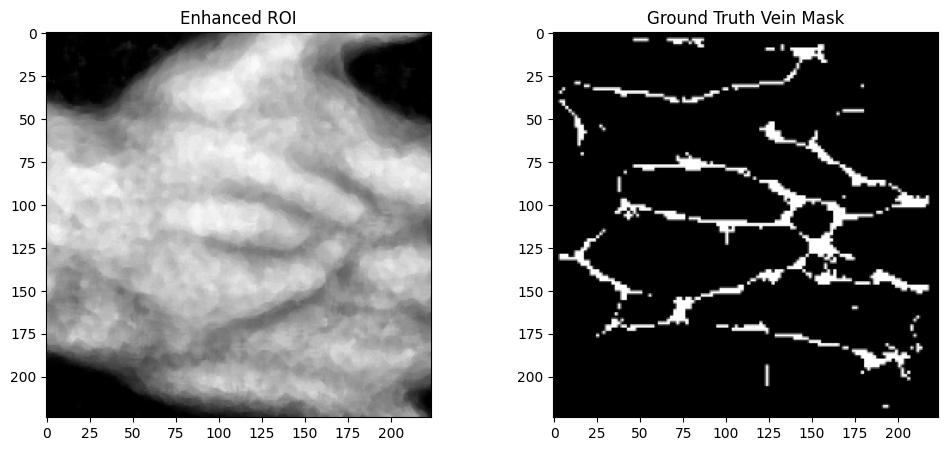

In [138]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(
    processed,
    cmap='gray'
)
plt.title(
    "Enhanced ROI"
)

plt.subplot(1,2,2)
plt.imshow(
    mask,
    cmap='gray'
)
plt.title(
    "Ground Truth Vein Mask"
)

plt.show()

PHASE 5: ATTENTION U-NET MODEL DEVELOPMENT

CELL 1 – IMPORT DEEP LEARNING LIBRARIES

In [139]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm

In [140]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [141]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10,p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(
        mean=(0.5,),
        std=(0.5,)
    ),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(
        mean=(0.5,),
        std=(0.5,)
    ),
    ToTensorV2()
])

In [143]:
class PalmVeinDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self,idx):

        image_path = self.df.iloc[idx]["image_path"]

        mask_path = self.df.iloc[idx]["mask_path"]

        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        image = preprocess_image(
            image
        )

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        mask = cv2.resize(
            mask,
            (224,224)
        )

        mask = (mask > 127).astype(np.float32)

        if self.transform:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        mask = torch.unsqueeze(
            mask,
            dim=0
        )

        return image.float(), mask.float()

In [144]:
train_dataset = PalmVeinDataset(
    train_df,
    train_transform
)

val_dataset = PalmVeinDataset(
    val_df,
    val_transform
)

test_dataset = PalmVeinDataset(
    test_df,
    val_transform
)

In [145]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

In [146]:
images,masks = next(
    iter(train_loader)
)

print(images.shape)

print(masks.shape)

torch.Size([8, 1, 224, 224])
torch.Size([8, 1, 224, 224])


In [147]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self,x):

        return self.conv(x)

In [148]:
class AttentionBlock(
    nn.Module
):

    def __init__(
        self,
        F_g,
        F_l,
        F_int
    ):

        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(
                F_g,
                F_int,
                1
            ),
            nn.BatchNorm2d(
                F_int
            )
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(
                F_l,
                F_int,
                1
            ),
            nn.BatchNorm2d(
                F_int
            )
        )

        self.psi = nn.Sequential(
            nn.Conv2d(
                F_int,
                1,
                1
            ),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(
            inplace=True
        )

    def forward(
        self,
        g,
        x
    ):

        psi = self.relu(
            self.W_g(g)
            +
            self.W_x(x)
        )

        psi = self.psi(
            psi
        )

        return x * psi

In [164]:
def train_one_epoch(loader, model, optimizer):

    model.train()

    running_loss = 0.0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        preds = model(images)

        loss = combined_loss(preds, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [165]:
def validate(loader, model):

    model.eval()

    running_loss = 0.0
    dice_score = 0.0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)

            loss = combined_loss(preds, masks)

            running_loss += loss.item()

            preds_bin = (torch.sigmoid(preds) > 0.5).float()

            intersection = (preds_bin * masks).sum()

            dice = (
                2.0 * intersection + 1e-8
            ) / (
                preds_bin.sum() + masks.sum() + 1e-8
            )

            dice_score += dice.item()

    return (
        running_loss / len(loader),
        dice_score / len(loader)
    )

In [166]:
NUM_EPOCHS = 50

best_dice = 0.0

train_losses = []
val_losses = []
val_dices = []

for epoch in range(NUM_EPOCHS):

    train_loss = train_one_epoch(
        train_loader,
        model,
        optimizer
    )

    val_loss, val_dice = validate(
        val_loader,
        model
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Dice: {val_dice:.4f}"
    )

    if val_dice > best_dice:

        best_dice = val_dice

        torch.save(
            model.state_dict(),
            "best_attention_unet.pth"
        )

        print("Best model saved!")

Epoch [1/50] Train Loss: 1.3357 Val Loss: 1.2861 Dice: 0.0000
Best model saved!
Epoch [2/50] Train Loss: 1.2502 Val Loss: 1.2416 Dice: 0.0000
Epoch [3/50] Train Loss: 1.2213 Val Loss: 1.2158 Dice: 0.0001
Best model saved!
Epoch [4/50] Train Loss: 1.2035 Val Loss: 1.2060 Dice: 0.0000
Epoch [5/50] Train Loss: 1.1867 Val Loss: 1.1690 Dice: 0.0008
Best model saved!
Epoch [6/50] Train Loss: 1.1723 Val Loss: 1.1547 Dice: 0.0058
Best model saved!
Epoch [7/50] Train Loss: 1.1611 Val Loss: 1.1453 Dice: 0.0083
Best model saved!
Epoch [8/50] Train Loss: 1.1486 Val Loss: 1.1351 Dice: 0.1079
Best model saved!
Epoch [9/50] Train Loss: 1.1396 Val Loss: 1.1331 Dice: 0.1548
Best model saved!
Epoch [10/50] Train Loss: 1.1331 Val Loss: 1.1123 Dice: 0.0819
Epoch [11/50] Train Loss: 1.1220 Val Loss: 1.1168 Dice: 0.1949
Best model saved!
Epoch [12/50] Train Loss: 1.1170 Val Loss: 1.1094 Dice: 0.1122
Epoch [13/50] Train Loss: 1.1069 Val Loss: 1.1054 Dice: 0.1782
Epoch [14/50] Train Loss: 1.1000 Val Loss: 1.1

In [158]:
NUM_EPOCHS = 50

In [159]:
torch.save(
    model.state_dict(),
    "best_attention_unet.pth"
)

In [160]:
model.load_state_dict(
    torch.load(
        "best_attention_unet.pth"
    )
)

<All keys matched successfully>

In [161]:
# Show:
# Input ROI
# Ground Truth Mask
# Predicted Mask